# Modelo de ML para predicción de demanda
El presente trabajo busca generar una herramienta basada en ML para predecir el cálculo de la demanda en un negocio en marcha con el objetivo de evitar quiebres de stock y su consecias en producción y pérdida de credibilidad en sus relaciones comerciales

# 1. Estructura base y definiciones



Definición de las librerías a utilizar así como dirección del contenedor de los datos, modelos y configuraciones de diseño para la presentación de información.

In [ ]:
#Librías a utilizar:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#Contenedor de la data
from google.colab import drive
drive.mount('/content/drive')
#Modelos y métricas
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
#Diseño
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 4)
pd.set_option("display.max_columns", 30)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Definición del catálogo de movimientos que el proyecto debe considerar para los procesos de análisis, normalización y preparación de la información ofrecida como input.

In [ ]:
#demanda : movimientos de mercadería que implique una salida o merma del
#          inventario que reste el stock actual.
#no_demanda : movimientos de mercaderia que no implique una salida de stock.

CLASIFICACION_MOVIMIENTOS = {
    #Movimientos de demanda
    "Ad" : "demanda",
    "Bd" : "demanda",
    "Cd" : "demanda",
    "Dd" : "demanda",
    "Ed" : "demanda",
    "Fd" : "demanda",
    "Gd" : "demanda",
    "Hd" : "demanda",
    "Id" : "demanda",
    "Jd" : "demanda",
    "Kd" : "demanda",
    "Ld" : "demanda",
    "Md" : "demanda",
    "Nd" : "demanda",
    #Movimientos de no_demanda
    "An" : "no_demanda",
    "Bn" : "no_demanda",
    "Cn" : "no_demanda",
    "Dn" : "no_demanda",
    "En" : "no_demanda",
    "Fn" : "no_demanda",
    "Gn" : "no_demanda",
    "Hn" : "no_demanda",
    "In" : "no_demanda",
    "Jn" : "no_demanda",
    "Kn" : "no_demanda",
    "Ln" : "no_demanda"
}
#Clasifica los movimientos del data set por "demanda" o "no_demanda" o
#"sin_clasificar" para tratar los datos.
def clasificar_movimientos(df, columna_clase="Clase de movimiento"):
    df = df.copy()
    df[columna_clase] = df[columna_clase].astype(str)
    df["grupo_movimiento"] = df[columna_clase].map(CLASIFICACION_MOVIMIENTOS).fillna("sin_clasificar")

    sin_clasificar = df[df["grupo_movimiento"] == "sin_clasificar"][columna_clase].unique()
    if len(sin_clasificar) > 0:
        print(f"Movimiento sin clasificar, revisar manualmente: {list(sin_clasificar)}")
    return df


# 2. Carga y normalización de datos

Definición de las funcionalidades que convertiran los datos del input en variables reconocibles para el modelo.

In [ ]:
def cargar_extracto(ruta_archivo, hoja="Data"):
    df = pd.read_excel(ruta_archivo, sheet_name=hoja, dtype={"Almacén":str})
    df["Fecha de entrada"] = pd.to_datetime(df["Fecha de entrada"])
    df["Almacén"] = df["Almacén"].fillna("SIN_ALM").astype(str)
    return df


def construir_serie_diaria(df):
    df = clasificar_movimientos(df)
    demanda = df[df["grupo_movimiento"] == "demanda"].copy()
    demanda["salida"] = demanda["Ctd.en UM entrada"].abs()

    diario = (
        demanda.groupby(["Material", "Centro", "Almacén", "Fecha de entrada"])["salida"]
        .sum()
        .reset_index()
        .rename(columns={"Fecha de entrada": "date", "salida": "demanda_diaria"})
    )

    combinaciones = diario[["Material", "Centro", "Almacén"]].drop_duplicates()
    rango_fechas = pd.date_range(df["Fecha de entrada"].min(), df["Fecha de entrada"].max(), freq="D")

    partes = []
    for _, fila in combinaciones.iterrows():
        calendario = pd.DataFrame({"date": rango_fechas})
        calendario["Material"] = fila["Material"]
        calendario["Centro"] = fila["Centro"]
        calendario["Almacén"] = fila["Almacén"]
        sub = diario[
            (diario["Material"] == fila["Material"]) &
            (diario["Centro"] == fila["Centro"]) &
            (diario["Almacén"] == fila["Almacén"])
        ]
        combinado = calendario.merge(sub[["date", "demanda_diaria"]], on="date", how="left")
        combinado["demanda_diaria"] = combinado["demanda_diaria"].fillna(0.0)
        partes.append(combinado)

    serie = pd.concat(partes, ignore_index=True)
    return serie, len(demanda), len(df)


def construir_features(serie, lags=(1, 3, 7, 14), ventanas=(7, 14)):
    serie = serie.sort_values(["Material", "Centro", "Almacén", "date"]).reset_index(drop=True)
    serie["day_of_week"] = serie["date"].dt.dayofweek
    serie["month"] = serie["date"].dt.month
    serie["is_weekend"] = (serie["day_of_week"] >= 5).astype(int)

    grupo_cols = ["Material", "Centro", "Almacén"]
    for lag in lags:
        serie[f"lag_{lag}"] = serie.groupby(grupo_cols)["demanda_diaria"].shift(lag)
    for w in ventanas:
        serie[f"rolling_mean_{w}"] = serie.groupby(grupo_cols)["demanda_diaria"].transform(
            lambda s, w=w: s.shift(1).rolling(window=w).mean()
        )
    return serie


def dividir_train_test(df_model, feature_cols, target_col="demanda_diaria", dias_test=30):
    fecha_corte = df_model["date"].max() - pd.Timedelta(days=dias_test)
    train = df_model[df_model["date"] < fecha_corte]
    test = df_model[df_model["date"] >= fecha_corte]
    return train[feature_cols], train[target_col], test[feature_cols], test[target_col], train, test


def entrenar_y_comparar(X_train, y_train, X_test, y_test):
    modelos = {
        "Ridge (baseline)": Ridge(alpha=1.0, random_state=RANDOM_STATE),
        "Random Forest": RandomForestRegressor(
            n_estimators=250, max_depth=8, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=-1
        ),
        "Gradient Boosting": HistGradientBoostingRegressor(
            max_iter=200, max_depth=5, learning_rate=0.05, random_state=RANDOM_STATE
        ),
    }
    predicciones, filas_metricas = {}, []
    for nombre, modelo in modelos.items():
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)
        predicciones[nombre] = y_pred
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        wmape = np.sum(np.abs(y_test - y_pred)) / np.sum(np.abs(y_test)) * 100
        filas_metricas.append({"Modelo": nombre, "MAE": mae, "RMSE": rmse, "R2": r2, "WMAPE (%)": wmape})

    df_metricas = pd.DataFrame(filas_metricas).sort_values("RMSE").reset_index(drop=True)
    return modelos, predicciones, df_metricas


Carga inicial de datos del input desde su contenedor.

In [ ]:
df_centro3 = cargar_extracto("/content/drive/My Drive/Maestria/Input.xlsx")
print("Movimientos cargados:", df_centro3.shape)
print("Centro(s):", df_centro3["Centro"].unique())
print("Almacenes:", sorted(df_centro3["Almacén"].fillna('SIN_ALM').astype(str).unique()))
print("Rango de fechas:", df_centro3["Fecha de entrada"].min().date(), "->", df_centro3["Fecha de entrada"].max().date())


Movimientos cargados: (39369, 9)
Centro(s): ['CE00' 'CE01' 'CE02' 'CE03']
Almacenes: ['0008', '0013', '0018', '0110', '0129', '0130', '0201', '0202', '0205', '0301', '0314', '0315', 'SIN_ALM']
Rango de fechas: 2025-05-01 -> 2026-06-30


Identificación de la demanda real y clasificaciión de la distribución.

In [ ]:
serie_c3, n_demanda_c3, n_total_c3 = construir_serie_diaria(df_centro3)
print(f"De {n_total_c3} movimientos, {n_demanda_c3} son demanda real de clientes "
      f"({n_demanda_c3/n_total_c3:.0%}).")
print()
print(serie_c3.groupby(["Centro","Material"])["demanda_diaria"].agg(
    dias_con_demanda=lambda s: (s > 0).sum(), total="sum", promedio_dia="mean"
))


De 39369 movimientos, 38114 son demanda real de clientes (97%).

                 dias_con_demanda       total  promedio_dia
Centro Material                                            
CE00   1                      262     896.400      0.526056
CE01   1                      321   95864.000     56.258216
CE02   1                      546   61004.724     35.800894
CE03   1                      328  102736.000     60.291080


Análisis inicial de la demanda diaria de los clientes por centro gráficado.

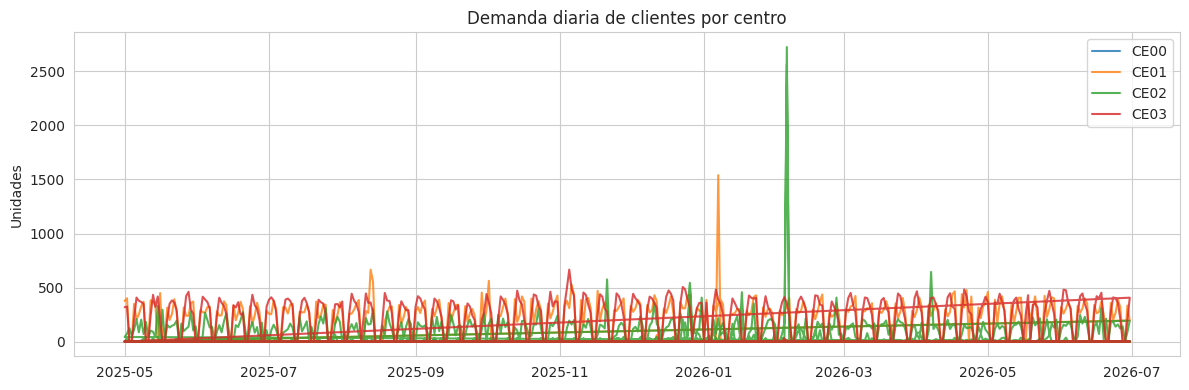

In [ ]:
# Gráfica de la serie diaria
fig, ax = plt.subplots(figsize=(12, 4))
for centro, grupo in serie_c3.groupby("Centro"):
    ax.plot(grupo["date"], grupo["demanda_diaria"], label=centro, alpha=0.8)
ax.set_title("Demanda diaria de clientes por centro")
ax.set_ylabel("Unidades")
ax.legend()
plt.tight_layout()
plt.savefig("/content/drive/My Drive/Maestria/fig_serie_centro3.png", dpi=110)
plt.show()


Aplicación de ingenieria de variables para la matriz de datos a utilizarse en el modelo ML.

In [ ]:
df_feat_c3 = construir_features(serie_c3)

cols_lag = [c for c in df_feat_c3.columns if c.startswith("lag_") or c.startswith("rolling_")]
df_model_c3 = df_feat_c3.dropna(subset=cols_lag).copy()
df_model_c3 = pd.get_dummies(df_model_c3, columns=["Almacén"], prefix="almacen")

feature_cols_c3 = [c for c in df_model_c3.columns if c not in
                   ["date", "demanda_diaria", "Material", "Centro"]]

print("Filas disponibles para entrenar:", len(df_model_c3))
print("Features:", feature_cols_c3)

Filas disponibles para entrenar: 6592
Features: ['day_of_week', 'month', 'is_weekend', 'lag_1', 'lag_3', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_mean_14', 'almacen_0008', 'almacen_0013', 'almacen_0018', 'almacen_0110', 'almacen_0129', 'almacen_0130', 'almacen_0201', 'almacen_0202', 'almacen_0205', 'almacen_0301', 'almacen_0314', 'almacen_0315', 'almacen_SIN_ALM']


# 3. Machine Learnig y evaluación

Toma los datos normalizados de los pasos anteriores y genera el modelado predictivo.

In [ ]:
X_train, y_train, X_test, y_test, train_c3, test_c3 = dividir_train_test(df_model_c3, feature_cols_c3)
print("Train:", X_train.shape, "| rango:", train_c3['date'].min().date(), "->", train_c3['date'].max().date())
print("Test :", X_test.shape,  "| rango:", test_c3['date'].min().date(), "->", test_c3['date'].max().date())

modelos_c3, predicciones_c3, metricas_c3 = entrenar_y_comparar(X_train, y_train, X_test, y_test)
metricas_c3


Train: (6096, 22) | rango: 2025-05-15 -> 2026-05-30
Test : (496, 22) | rango: 2026-05-31 -> 2026-06-30


,Modelo,MAE,RMSE,R2,WMAPE (%)
0,Gradient Boosting,9.888774,27.077722,0.926786,26.768495
1,Random Forest,10.855434,31.561454,0.900531,29.385203
2,Ridge (baseline),21.863767,39.755281,0.842180,59.184300


Ayuda visual para comparar los modelos.

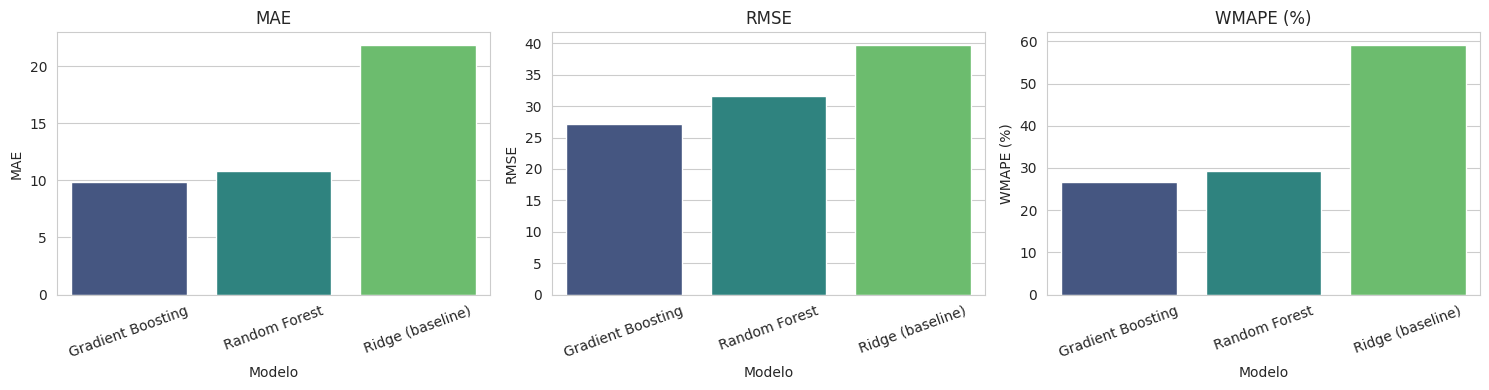

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metrica in zip(axes, ["MAE", "RMSE", "WMAPE (%)"]):
    sns.barplot(data=metricas_c3, x="Modelo", y=metrica, hue="Modelo", ax=ax, palette="viridis", legend=False)
    ax.set_title(metrica)
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig("/content/drive/My Drive/Maestria/fig_comparativa_metricas_centro3.png", dpi=110)
plt.show()

Validación visual de lo proyectado vs lo real considerando el ranfo de test planteado en el bloque anterior.

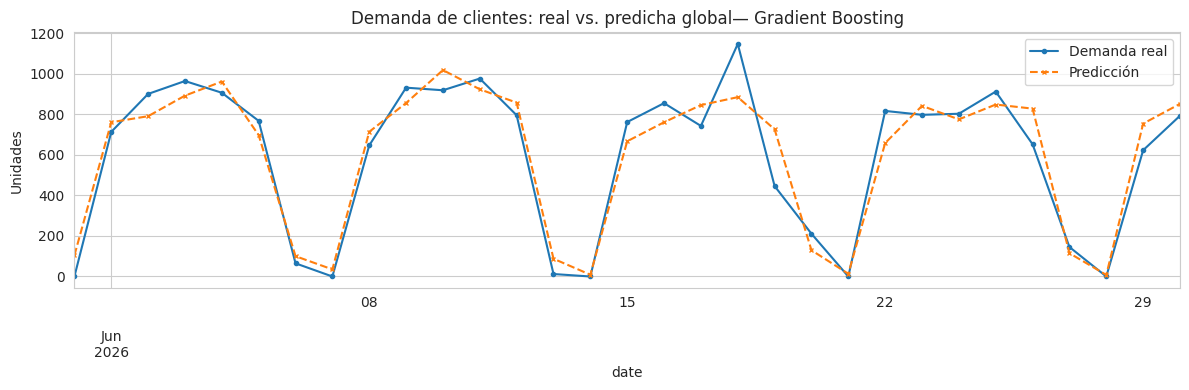

Mejor modelo según RMSE: Gradient Boosting


In [ ]:
mejor_modelo_c3 = metricas_c3.iloc[0]["Modelo"]
y_pred_mejor_c3 = predicciones_c3[mejor_modelo_c3]

comparacion = test_c3[["date", "demanda_diaria"]].copy()
comparacion["prediccion"] = y_pred_mejor_c3
comparacion_agg = comparacion.groupby("date").sum(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 4))
comparacion_agg["demanda_diaria"].plot(ax=ax, label="Demanda real", linewidth=1.5, marker="o", markersize=3)
comparacion_agg["prediccion"].plot(ax=ax, label="Predicción", linewidth=1.5, linestyle="--", marker="x", markersize=3)
ax.set_title(f"Demanda de clientes: real vs. predicha global— {mejor_modelo_c3}")
ax.set_ylabel("Unidades")
ax.legend()
plt.tight_layout()
plt.savefig("/content/drive/My Drive/Maestria/fig_real_vs_prediccion_centro3.png", dpi=110)
plt.show()

print(f"Mejor modelo según RMSE: {mejor_modelo_c3}")

Definición de la temporalidad

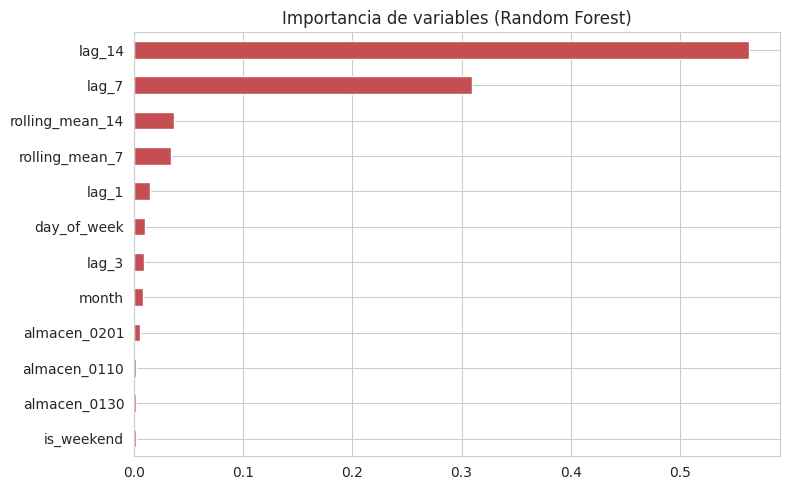

,0
lag_14,0.563496
lag_7,0.309348
rolling_mean_14,0.036940
rolling_mean_7,0.033606
lag_1,0.014995
day_of_week,0.009854
lag_3,0.009335
month,0.008291
almacen_0201,0.005878
almacen_0110,0.002245


In [ ]:
importancias_c3 = pd.Series(
    modelos_c3["Random Forest"].feature_importances_, index=feature_cols_c3
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
importancias_c3.head(12).sort_values().plot(kind="barh", ax=ax, color="#C44E52")
ax.set_title("Importancia de variables (Random Forest)")
plt.tight_layout()
plt.savefig("/content/drive/My Drive/Maestria/fig_feature_importance_centro3.png", dpi=110)
plt.show()

importancias_c3.head(10)

# 4. Resultados y proyección

Ejecución del modelo ganador a cada centro reconocido en el día inmediato posterior al de la última fecha leída en el data set (predicción de la demanda).

In [ ]:
def predecir_demanda_siguiente_dia(
    serie_con_features,
    centro,
    almacen,
    fecha_objetivo,
    modelos,
    mejor_modelo,
    feature_cols,
    lags=(1, 3, 7, 14),
    ventanas=(7, 14)
):
    modelo = modelos[mejor_modelo]
    fecha_objetivo = pd.to_datetime(fecha_objetivo)

    # Filtrar por Centro y Almacén
    serie = serie_con_features[
        (serie_con_features["Centro"] == centro) &
        (serie_con_features["Almacén"] == almacen)
    ].sort_values("date")

    serie = serie[serie["date"] < fecha_objetivo]

    if len(serie) < max(lags + ventanas):
        raise ValueError("Historial insuficiente para calcular todas las features requeridas.")

    ultimos = serie.set_index("date")["demanda_diaria"]

    fila = {
        "day_of_week": fecha_objetivo.dayofweek,
        "month": fecha_objetivo.month,
        "is_weekend": int(fecha_objetivo.dayofweek >= 5),
    }

    for lag in lags:
        fila[f"lag_{lag}"] = ultimos.iloc[-lag]

    for w in ventanas:
        fila[f"rolling_mean_{w}"] = ultimos.iloc[-w:].mean()

    # Asignar 1 al almacén objetivo y 0 a los demás (coincidiendo con las columnas de entrenamiento)
    for c in feature_cols:
        if c.startswith("almacen_"):
            fila[c] = 1 if c == f"almacen_{almacen}" else 0

    X_nuevo = pd.DataFrame([fila])[feature_cols]
    prediccion = modelo.predict(X_nuevo)[0]
    return max(round(float(prediccion), 2), 0.0)


fecha_siguiente = df_model_c3["date"].max() + pd.Timedelta(days=1)
print(f"--- PREDICCIÓN PARA EL DÍA SIGUIENTE ({fecha_siguiente.date()}) POR CENTRO ---")

# Buscamos el almacén más representativo (de mayor volumen) para cada centro
centros_unicos = sorted(serie_c3["Centro"].unique())

for centro in centros_unicos:
    # Identificar el almacén top de este centro
    sub_centro = serie_c3[serie_c3["Centro"] == centro]
    almacen_top = sub_centro.groupby("Almacén")["demanda_diaria"].sum().idxmax()

    pred = predecir_demanda_siguiente_dia(
        serie_con_features=df_feat_c3,
        centro=centro,
        almacen=almacen_top,
        fecha_objetivo=fecha_siguiente,
        modelos=modelos_c3,
        mejor_modelo=mejor_modelo_c3,
        feature_cols=feature_cols_c3
    )
    print(f"Centro: {centro} | Almacén principal: {almacen_top:<6} -> requiere: {pred:>7.2f} unidades")

--- PREDICCIÓN PARA EL DÍA SIGUIENTE (2026-07-01) POR CENTRO ---
Centro: CE00 | Almacén principal: 0008   -> requiere:    1.16 unidades
Centro: CE01 | Almacén principal: 0110   -> requiere:  271.06 unidades
Centro: CE02 | Almacén principal: 0202   -> requiere:    3.30 unidades
Centro: CE03 | Almacén principal: 0301   -> requiere:  402.88 unidades


Proyección a 12 semanas (3 meses) de demanda considerando el modelo ganador y con un data set con información histórica de 1 año.

In [ ]:
semanas_proyeccion = 12
dias_totales = semanas_proyeccion * 7
fecha_inicio = df_model_c3["date"].max() + pd.Timedelta(days=1)
rango_fechas = pd.date_range(fecha_inicio, periods=dias_totales, freq="D")

# Estrae las parejas activas de Centro y Almacén
combinaciones = serie_c3[["Centro", "Almacén", "Material"]].drop_duplicates()

# Copia de simulación para retroalimentar las predicciones
df_simulacion = df_feat_c3.copy()
registros_proyeccion = []

print(f"Generando proyección diaria para {len(combinaciones)} almacenes durante {dias_totales} días...")

for fecha in rango_fechas:
    for _, fila in combinaciones.iterrows():
        c = fila["Centro"]
        alm = fila["Almacén"]
        mat = fila["Material"]

        try:
            pred = predecir_demanda_siguiente_dia(
                serie_con_features=df_simulacion,
                centro=c,
                almacen=alm,
                fecha_objetivo=fecha,
                modelos=modelos_c3,
                mejor_modelo=mejor_modelo_c3,
                feature_cols=feature_cols_c3
            )
        except ValueError:
            pred = 0.0  # En caso de que un almacen no tenga suficiente historial base

        registros_proyeccion.append({
            "Fecha": fecha,
            "Semana": f"Semana {fecha.isocalendar().week}",
            "Centro": c,
            "Almacén": alm,
            "Demanda_Predicha": pred
        })

        nueva_fila = pd.DataFrame([{
            "date": fecha,
            "Centro": c,
            "Almacén": alm,
            "Material": mat,
            "demanda_diaria": pred
        }])
        df_simulacion = pd.concat([df_simulacion, nueva_fila], ignore_index=True)

df_proyeccion_total = pd.DataFrame(registros_proyeccion)

# se procesa la agrupación por centro y semana, sumando la demanda de todos los días de la semana
resumen_semanal = df_proyeccion_total.groupby(
    ["Semana", "Centro"], as_index=False
)["Demanda_Predicha"].sum()

# Semanas en filas, centros en columnas
tabla_semanal_centros = resumen_semanal.pivot(
    index="Semana",
    columns="Centro",
    values="Demanda_Predicha"
).fillna(0).round(2)

# Se añade la columna TOTAL por semana y la fila TOTAL de las 12 semanas
tabla_semanal_centros["TOTAL_GLOBAL"] = tabla_semanal_centros.sum(axis=1).round(2)
fila_total = tabla_semanal_centros.sum(axis=0).round(2)
fila_total.name = "TOTAL_12_SEMANAS"
tabla_final_12w = pd.concat([tabla_semanal_centros, fila_total.to_frame().T])

print("\n--- PRONÓSTICO DE DEMANDA SEMANAL CONSOLIDADO POR CENTRO (12 SEMANAS) ---")
display(tabla_final_12w)

Generando proyección diaria para 16 almacenes durante 84 días...

--- PRONÓSTICO DE DEMANDA SEMANAL CONSOLIDADO POR CENTRO (12 SEMANAS) ---


Centro,CE00,CE01,CE02,CE03,TOTAL_GLOBAL
Semana 27,6.74,914.81,651.00,1034.31,2606.86
Semana 28,136.32,1685.73,957.76,1894.97,4674.78
Semana 29,122.31,1685.39,1008.44,1820.09,4636.23
Semana 30,102.20,1743.60,967.20,1685.38,4498.38
Semana 31,52.85,1733.55,949.19,1687.24,4422.83
Semana 32,75.09,1794.61,990.48,1701.18,4561.36
Semana 33,123.66,1749.37,1013.45,1794.71,4681.19
Semana 34,72.10,1775.56,959.47,1704.24,4511.37
Semana 35,57.87,1702.03,975.56,1724.12,4459.58
Semana 36,130.86,1802.96,971.93,1704.99,4610.74
